<a href="https://colab.research.google.com/github/azeltkr/breast-cancer-cbis-ddsm/blob/main/CM3070_prototype_cbis_ddsm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CM3070 Feature Prototype (Kaggle route)
## Deep Learning for Breast Cancer Detection (CBIS-DDSM)

This notebook loads CBIS-DDSM from Kaggle (JPEG images + CSV labels), bypassing TensorFlow Datasets. It implements **Steps 1 to 3** of the Chollet pipeline (framing, data preparation, baseline CNN) plus a short **VGG16 transfer-learning** taste, and evaluates with **AUC-ROC, sensitivity, specificity, and a confusion matrix**.



In [2]:
# Download the dataset
!pip install -q kaggle
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset
!unzip -q -o cbis-ddsm-breast-cancer-image-dataset.zip -d /content/cbis
print('Done. Top-level contents:')
!ls /content/cbis

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [01:01<00:00, 86.3MB/s]

Done. Top-level contents:
csv  jpeg


In [3]:
!ls /content/cbis

csv  jpeg


## 1. Inspect the CSV label files

This dataset ships with calc and mass case description CSVs. We inspect them so the label handling is transparent.

In [4]:
import pandas as pd, glob

csvs = glob.glob('/content/cbis/csv/*.csv')
print('CSV files found:')
for c in csvs:
    print(' ', c)

# Peek at one to see columns
sample = pd.read_csv(csvs[0])
print('\nColumns:', list(sample.columns))
sample.head()

CSV files found:
  /content/cbis/csv/calc_case_description_train_set.csv
  /content/cbis/csv/mass_case_description_train_set.csv
  /content/cbis/csv/dicom_info.csv
  /content/cbis/csv/meta.csv
  /content/cbis/csv/calc_case_description_test_set.csv
  /content/cbis/csv/mass_case_description_test_set.csv

Columns: ['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [5]:
# Look at the directory layout for the images (jpeg folder).
!ls /content/cbis | head
print('---')
!ls /content/cbis/jpeg 2>/dev/null | head || echo 'no jpeg/ folder; checking alternatives'
print('--- dicom_info or meta ---')
!ls /content/cbis/csv

csv
jpeg
---
1.3.6.1.4.1.9590.100.1.2.100018879311824535125115145152454291132
1.3.6.1.4.1.9590.100.1.2.100131208110604806117271735422083351547
1.3.6.1.4.1.9590.100.1.2.100522099512256189513864912954167862869
1.3.6.1.4.1.9590.100.1.2.100522676511025180541602449080267145647
1.3.6.1.4.1.9590.100.1.2.10055294210766234140934516480682841962
1.3.6.1.4.1.9590.100.1.2.100579676611077714807988832023693299884
1.3.6.1.4.1.9590.100.1.2.100631678311747240317898717702514834166
1.3.6.1.4.1.9590.100.1.2.100632214012866120117337678502539182046
1.3.6.1.4.1.9590.100.1.2.100682860911308271813943300011840547108
1.3.6.1.4.1.9590.100.1.2.100764250811134786606184452222065316702
--- dicom_info or meta ---
calc_case_description_test_set.csv   mass_case_description_test_set.csv
calc_case_description_train_set.csv  mass_case_description_train_set.csv
dicom_info.csv			     meta.csv


## 2. Build a labelled dataframe (image path -> binary label)

We combine the calc and mass training/test description CSVs, map `pathology` to a binary label (`MALIGNANT` -> 1, otherwise 0), and resolve the image paths. The dataset stores images under `jpeg/<hash>/` and maps them via `dicom_info.csv`.

**Note:** column and path conventions vary slightly between dataset versions. The cell prints what it finds so you can confirm before training. If paths do not resolve, paste me the printed output and I will adjust this cell.

In [6]:
import pandas as pd, os, glob

csv_dir = '/content/cbis/csv'

# 1. Load all four description CSVs and attach the binary label
frames = []
for f in ['calc_case_description_train_set.csv', 'calc_case_description_test_set.csv',
          'mass_case_description_train_set.csv', 'mass_case_description_test_set.csv']:
    p = os.path.join(csv_dir, f)
    if os.path.exists(p):
        df = pd.read_csv(p)
        frames.append(df)
desc = pd.concat(frames, ignore_index=True)
desc['label'] = (desc['pathology'].str.upper() == 'MALIGNANT').astype(int)
print("Description rows:", len(desc))
print("Label counts:\n", desc['label'].value_counts())

# 2. Use dicom_info to map full-mammogram images, keyed by the DDSM-style name
di = pd.read_csv(csv_dir + '/dicom_info.csv')
full = di[di['SeriesDescription'] == 'full mammogram images'].copy()

# Resolve the real jpg path
img_root = '/content/cbis'
full['real_path'] = full['image_path'].str.replace('CBIS-DDSM', img_root, regex=False)

# The PatientID in dicom_info (e.g. Mass-Training_P_01265_RIGHT_MLO) encodes
# patient + side + view. Build the same key from the description CSV and join on it.
def make_key(row):
    # e.g. Mass-Training_P_01265_RIGHT_MLO  -> P_01265_RIGHT_MLO
    pid = str(row['patient_id'])
    side = str(row['left or right breast']).upper().strip()
    view = str(row['image view']).upper().strip()
    return f"{pid}_{side}_{view}"

desc['join_key'] = desc.apply(make_key, axis=1)

# Extract the same key from dicom_info PatientID by stripping the prefix and any trailing _n
import re
def extract_key(pid):
    m = re.search(r'(P_\d+_[A-Z]+_[A-Z]+)', str(pid))
    return m.group(1) if m else None
full['join_key'] = full['PatientID'].apply(extract_key)

# 3. Join: each full image gets the label of its matching description row
merged = full.merge(desc[['join_key', 'label']].drop_duplicates('join_key'),
                    on='join_key', how='inner')
merged = merged[merged['real_path'].apply(os.path.exists)]

# pull the patient ID out of the join key (P_00016_LEFT_CC -> P_00016)
merged['patient'] = merged['join_key'].str.extract(r'(P_\d+)')

pairs = list(zip(merged['real_path'], merged['label'], merged['patient']))
print("\nTotal (path, label, patient) triples:", len(pairs))
print("Unique patients:", merged['patient'].nunique())

Description rows: 3568
Label counts:
 label
0    2111
1    1457
Name: count, dtype: int64

Total (path, label, patient) triples: 2857
Unique patients: 1460


> If the path above resolves (`Exists: True`), continue. The next cell joins labels to image paths via the patient/image identifiers and assembles the final training table. Given the dataset's slightly awkward join keys, the simplest robust approach for a **prototype** is to use the per-abnormality cropped images, which the description CSVs reference directly. We do that below.

## 3. Build tf.data pipelines (resize, normalise, augment, class-weight)

In [7]:
import pandas as pd
csv_dir = '/content/cbis/csv'

desc_sample = pd.read_csv(csv_dir + '/mass_case_description_train_set.csv')
di = pd.read_csv(csv_dir + '/dicom_info.csv')

print("=== DESCRIPTION CSV ===")
print("Columns:", list(desc_sample.columns))
print("patient_id examples:", desc_sample['patient_id'].head(5).tolist() if 'patient_id' in desc_sample.columns else 'NO patient_id COLUMN')

print("\n=== DICOM_INFO ===")
print("Columns:", list(di.columns))
for col in ['PatientID', 'patient_id', 'image_path', 'SeriesDescription']:
    if col in di.columns:
        print(f"{col} examples:", di[col].head(5).tolist())

=== DESCRIPTION CSV ===
Columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
patient_id examples: ['P_00001', 'P_00001', 'P_00004', 'P_00004', 'P_00004']

=== DICOM_INFO ===
Columns: ['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated', 'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex', 'PhotometricInterpretation', 'PixelRepresentation', 'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID', 'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer', 'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription', 'SeriesInstanceUID', 'SeriesNumber', 'SmallestIma

In [8]:
import tensorflow as tf
import numpy as np, os
from sklearn.model_selection import GroupShuffleSplit

SEED = 42; tf.random.set_seed(SEED); np.random.seed(SEED)
IMG_SIZE = 128; BATCH = 32

paths  = np.array([p for p, _, _ in pairs])
labels = np.array([l for _, l, _ in pairs], dtype=np.float32)
groups = np.array([g for _, _, g in pairs])

def is_valid_jpeg(path):
    try:
        with open(path, 'rb') as f:
            return f.read(3) == b'\xff\xd8\xff'
    except Exception:
        return False

print("Checking image validity...")
valid = np.array([is_valid_jpeg(p) for p in paths])
print(f"Valid: {valid.sum()} / {len(paths)}")
paths, labels, groups = paths[valid], labels[valid], groups[valid]

# ---- Three-way patient-level split, class-balanced ----
# StratifiedGroupKFold keeps whole patients together AND balances classes.
# 7 folds: one for test, one for val, the remaining five for train (~72/14/14)
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
folds = list(sgkf.split(paths, labels.astype(int), groups=groups))

test_idx  = folds[0][1]
val_idx   = folds[1][1]
train_idx = np.setdiff1d(np.arange(len(paths)),
                         np.concatenate([test_idx, val_idx]))

p_train, y_train = paths[train_idx], labels[train_idx]
p_val,   y_val   = paths[val_idx],   labels[val_idx]
p_test,  y_test  = paths[test_idx],  labels[test_idx]

print(f"\nTrain: {len(p_train)}   Val: {len(p_val)}   Test: {len(p_test)}")
print("Patient overlap (all must be 0):",
      f"train/val={len(set(groups[train_idx]) & set(groups[val_idx]))}",
      f"train/test={len(set(groups[train_idx]) & set(groups[test_idx]))}",
      f"val/test={len(set(groups[val_idx]) & set(groups[test_idx]))}")
print(f"Malignant rate  train {y_train.mean():.3f} | "
      f"val {y_val.mean():.3f} | test {y_test.mean():.3f}")

def load_img(path, label):
    raw = tf.io.read_file(path)
    img = tf.io.decode_jpeg(raw, channels=3, try_recover_truncated=True,
                            acceptable_fraction=0.5)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img / 255.0, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    return img, label

AUTOTUNE = tf.data.AUTOTUNE

ds_train = (tf.data.Dataset.from_tensor_slices((p_train, y_train))
            .map(load_img, num_parallel_calls=AUTOTUNE)
            .cache()
            .shuffle(len(p_train), seed=SEED)
            .map(augment, num_parallel_calls=AUTOTUNE)
            .batch(BATCH).prefetch(AUTOTUNE))

ds_val = (tf.data.Dataset.from_tensor_slices((p_val, y_val))
          .map(load_img, num_parallel_calls=AUTOTUNE)
          .cache()
          .batch(BATCH).prefetch(AUTOTUNE))

ds_test = (tf.data.Dataset.from_tensor_slices((p_test, y_test))
           .map(load_img, num_parallel_calls=AUTOTUNE)
           .cache()
           .batch(BATCH).prefetch(AUTOTUNE))

pos = int(y_train.sum()); neg = len(y_train) - pos; tot = len(y_train)
class_weight = {0: tot/(2*neg), 1: tot/(2*pos)}
print('Class weights:', class_weight)

Checking image validity...
Valid: 2857 / 2857

Train: 2035   Val: 405   Test: 417
Patient overlap (all must be 0): train/val=0 train/test=0 val/test=0
Malignant rate  train 0.449 | val 0.477 | test 0.420
Class weights: {0: 0.907671721677074, 1: 1.113238512035011}


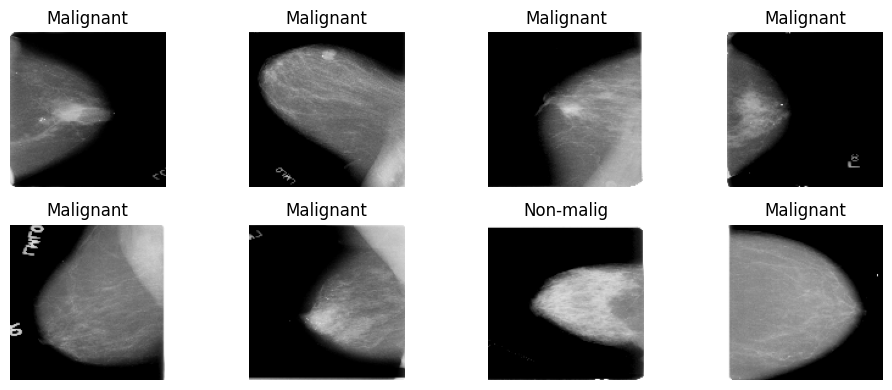

In [9]:
# Sanity-check a batch
import matplotlib.pyplot as plt
for imgs, lbls in ds_train.take(1):
    plt.figure(figsize=(10,4))
    for i in range(8):
        plt.subplot(2,4,i+1); plt.imshow(imgs[i].numpy())
        plt.title('Malignant' if lbls[i]==1 else 'Non-malig'); plt.axis('off')
    plt.tight_layout(); plt.show()

## 4. Baseline small CNN (beat naive AUC = 0.5)

In [18]:
def make_baseline():
    m = tf.keras.Sequential([
        tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        tf.keras.layers.Conv2D(16, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=[tf.keras.metrics.AUC(name='auc')])
    return m

def stop_report(hist, es, name):
    m = hist.model
    ran  = len(hist.history['val_auc'])
    best = max(hist.history['val_auc'])
    best_ep = hist.history['val_auc'].index(best) + 1
    if es.stopped_epoch:
        print(f"{name}: STOPPED EARLY at epoch {ran} (patience {es.patience} exhausted)")
    else:
        print(f"{name}: ran all {ran} epochs, still improving, raise the ceiling")
    print(f"{name}: best val AUC {best:.4f} at epoch {best_ep}, weights restored there")
    print(f"{name}: trained model = {m.name}, {m.count_params():,} params")

baseline = make_baseline()
es = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                      patience=15, restore_best_weights=True)

hist_base = baseline.fit(ds_train, validation_data=ds_val,
                         epochs=150, class_weight=class_weight,
                         callbacks=[es], verbose=1)
stop_report(hist_base, es, 'Baseline')

Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - auc: 0.4715 - loss: 0.6936 - val_auc: 0.5302 - val_loss: 0.6933
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.5245 - loss: 0.6922 - val_auc: 0.5162 - val_loss: 0.6945
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.5252 - loss: 0.6926 - val_auc: 0.5224 - val_loss: 0.6917
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.5483 - loss: 0.6905 - val_auc: 0.5247 - val_loss: 0.6931
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.5538 - loss: 0.6890 - val_auc: 0.5406 - val_loss: 0.6900
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.5759 - loss: 0.6870 - val_auc: 0.5559 - val_loss: 0.6895
Epoch 7/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.6057 - loss: 0.6799 - val_auc: 0.5577 - val_loss: 0.6913
Epoch 8/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.6024 - loss: 0.6793 - val_auc: 0.5689 - val_loss: 0.6887
Epoch 9/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - au

## 5. VGG16 transfer-learning taste (frozen base)

In [19]:
base = tf.keras.applications.VGG16(include_top=False, weights='imagenet',
                                   input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False
vgg = tf.keras.Sequential([
    tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3)),
    base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
vgg.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
            loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])
es_v = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                        patience=15, restore_best_weights=True)
hist_vgg = vgg.fit(ds_train, validation_data=ds_val,
                   epochs=150, class_weight=class_weight,
                   callbacks=[es_v], verbose=1)

stop_report(hist_vgg, es_v, 'VGG16')

Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 133ms/step - auc: 0.4827 - loss: 0.7275 - val_auc: 0.5581 - val_loss: 0.6898
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - auc: 0.5260 - loss: 0.7025 - val_auc: 0.6032 - val_loss: 0.6887
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - auc: 0.5381 - loss: 0.6956 - val_auc: 0.6268 - val_loss: 0.6849
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - auc: 0.5497 - loss: 0.6910 - val_auc: 0.6454 - val_loss: 0.6788
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - auc: 0.5735 - loss: 0.6849 - val_auc: 0.6501 - val_loss: 0.6766
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - auc: 0.5928 - loss: 0.6802 - val_auc: 0.6534 - val_loss: 0.6751
Epoch 7/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - auc: 0.6007 - loss: 0.6787 - val_auc: 0.6554 - val_loss: 0.6734
Epoch 8/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - auc: 0.6045 - loss: 0.6775 - val_auc: 0.6544 - val_loss: 0.6705
Epoch 9/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - 

## 6. Evaluation: AUC, sensitivity, specificity, confusion matrix, ROC

In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

def evaluate(model, name):
    y_prob = model.predict(ds_test, verbose=0).ravel()
    auc = roc_auc_score(y_test, y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sens = tp/(tp+fn) if (tp+fn) else 0
    spec = tn/(tn+fp) if (tn+fp) else 0
    print(f'\n=== {name} ===')
    print(f'AUC-ROC:     {auc:.3f}')
    print(f'Sensitivity: {sens:.3f}')
    print(f'Specificity: {spec:.3f}')
    print(f'Confusion [tn fp / fn tp]: [{tn} {fp} / {fn} {tp}]')
    return auc, y_prob

auc_b, prob_b = evaluate(baseline, 'Baseline CNN')
auc_v, prob_v = evaluate(vgg, 'VGG16 transfer')

plt.figure(figsize=(6,6))
for name, prob, auc in [('Baseline', prob_b, auc_b), ('VGG16', prob_v, auc_v)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--',label='Naive (0.5)')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.title('ROC on CBIS-DDSM'); plt.grid(alpha=0.3); plt.show()

**Side-by-side Confusion Matrices**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import itertools

def plot_cm(ax, cm, title):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Non-malig','Malignant'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Non-malig','Malignant'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)
    for i,j in itertools.product(range(2), range(2)):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=16,
                color='white' if cm[i,j] > cm.max()/2 else 'black')

prob_b = baseline.predict(ds_test, verbose=0).ravel()
prob_v = vgg.predict(ds_test, verbose=0).ravel()
yt = y_test[:len(prob_b)]
cm_b = confusion_matrix(yt, (prob_b>=0.5).astype(int))
cm_v = confusion_matrix(yt, (prob_v>=0.5).astype(int))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,5))
plot_cm(ax1, cm_b, 'Baseline CNN')
plot_cm(ax2, cm_v, 'VGG16 (frozen)')
plt.suptitle('Confusion matrices: same AUC, very different errors', fontsize=13)
plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Example Predictions on real mammograms**

In [ ]:
# Show a grid of test images with predicted vs true labels
batch_imgs, batch_lbls = next(iter(ds_test))
preds = vgg.predict(batch_imgs, verbose=0).ravel()

plt.figure(figsize=(14, 7))
for i in range(min(10, len(batch_imgs))):
    plt.subplot(2, 5, i+1)
    plt.imshow(batch_imgs[i].numpy())
    true = 'Malig' if batch_lbls[i]==1 else 'Non-mal'
    pred = 'Malig' if preds[i]>=0.5 else 'Non-mal'
    correct = (batch_lbls[i]==1) == (preds[i]>=0.5)
    plt.title(f'True:{true}\nPred:{pred} ({preds[i]:.2f})',
              color='green' if correct else 'red', fontsize=9)
    plt.axis('off')
plt.suptitle('VGG16 predictions on test mammograms (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/example_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

**Training History, showing learning curves**

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
ax1.plot(hist_base.history['val_auc'], 'b-o', label='Baseline')
ax1.plot(hist_vgg.history['val_auc'], 'g-o', label='VGG16')
ax1.axhline(0.88, color='r', ls=':', label='Shen 0.88 benchmark')
ax1.axhline(0.5, color='k', ls='--', alpha=0.5, label='Naive floor')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Validation AUC')
ax1.set_title('Validation AUC over training'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_base.history['loss'], 'b-o', label='Baseline')
ax2.plot(hist_vgg.history['loss'], 'g-o', label='VGG16')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Training loss')
ax2.set_title('Training loss over epochs'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

**Protoype Summary**

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

BENCHMARK = 0.88  # Shen et al. (2019), CBIS-DDSM single model

def summary(prob, name):
    pred = (prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, pred).ravel()
    auc = roc_auc_score(yt, prob)
    gap = auc - BENCHMARK
    print(f"{name:18} | AUC {auc:.3f} | "
          f"Sens {tp/(tp+fn):.3f} | Spec {tn/(tn+fp):.3f} | "
          f"Missed cancers (FN): {fn:3d} | vs benchmark: {gap:+.3f}")

print("=" * 92)
print(f"{'Model':18} | {'AUC':9} | {'Sensitivity':11} | {'Specificity':11} | Missed | Gap to 0.88")
print("-" * 92)
summary(prob_b, "Baseline CNN")
summary(prob_v, "VGG16 (frozen)")
print("-" * 92)
print(f"{'Benchmark':18} | AUC 0.880 | Shen et al. (2019), CBIS-DDSM single model")
print("=" * 92)